In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller


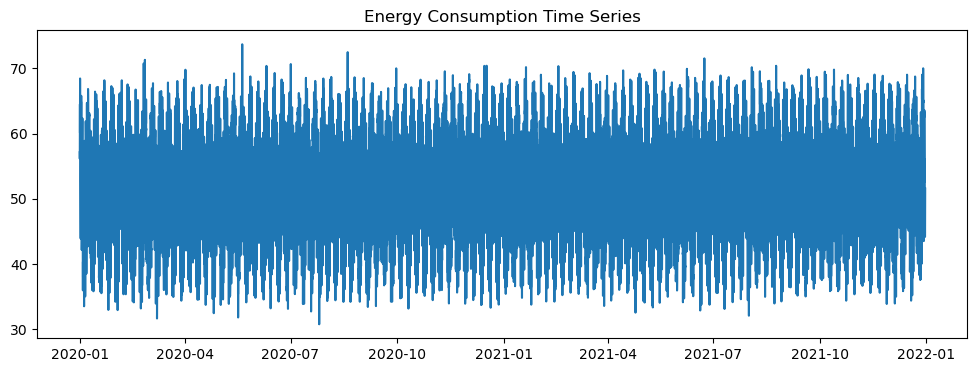

In [2]:
df = pd.read_csv("energy_consumption.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

plt.figure(figsize=(12,4))
plt.plot(df['consumption'])
plt.title("Energy Consumption Time Series")
plt.show()

In [3]:
df_daily = df['consumption'].resample('D').mean()
df_daily = df_daily.interpolate()

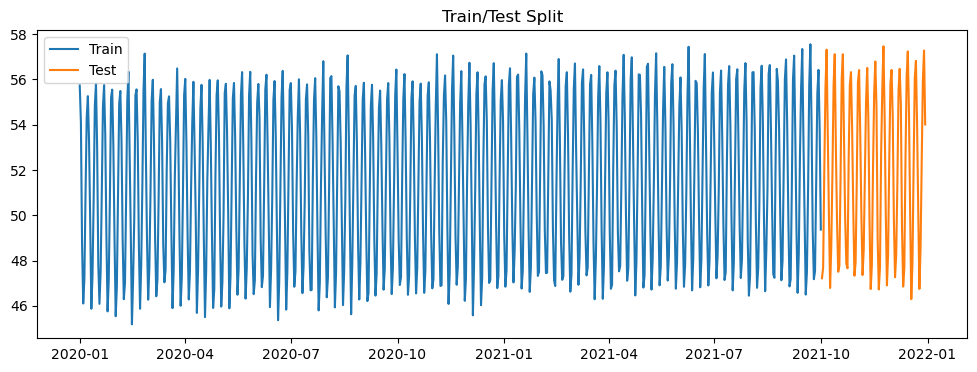

In [4]:
test_days = 90
train = df_daily[:-test_days]
test = df_daily[-test_days:]

plt.figure(figsize=(12,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.legend()
plt.title("Train/Test Split")
plt.show()

In [5]:
adf_res = adfuller(train)
print("ADF Statistic:", adf_res[0], "p-value:", adf_res[1])

ADF Statistic: -2.0119429887666285 p-value: 0.2813611910075503


C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best ARIMA order: (2, 0, 2)


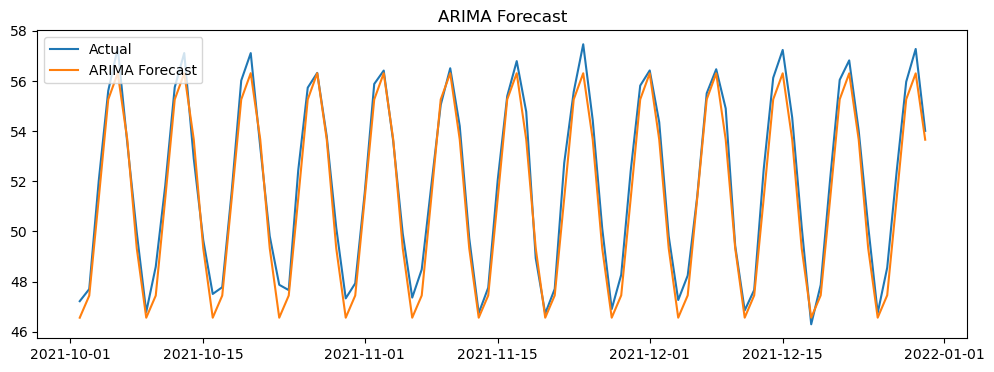

ARIMA -> MAE: 0.5746878677560232 RMSE: 0.670161002205178 MAPE: 1.1069818602100427


In [6]:
best_aic = np.inf
best_order = None
best_model = None

for p in range(0,3):
    for d in range(0,3):
        for q in range(0,3):
            try:
                model = ARIMA(train, order=(p,d,q)).fit()
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p,d,q)
                    best_model = model
            except:
                continue

print("Best ARIMA order:", best_order)

arima_forecast = best_model.get_forecast(steps=len(test))
arima_pred = arima_forecast.predicted_mean

plt.figure(figsize=(12,4))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, arima_pred, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)/y_true)) * 100

arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mape(test.values, arima_pred.values)

print("ARIMA -> MAE:", arima_mae, "RMSE:", arima_rmse, "MAPE:", arima_mape)


C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Neha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Lik

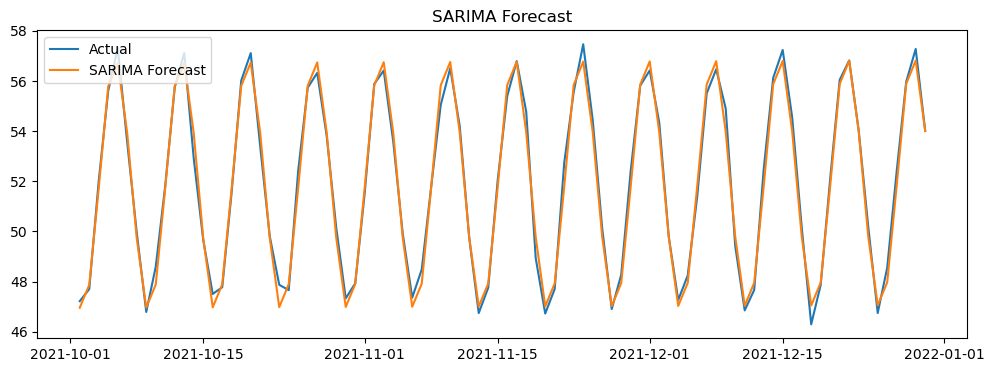

SARIMA -> MAE: 0.3397411356679113 RMSE: 0.4173561306391073 MAPE: 0.6553476626992532


In [7]:
s = 7   # weekly seasonality
best_aic = np.inf
best_sarima = None

for p in range(0,2):
    for d in range(0,2):
        for q in range(0,2):
            for P in range(0,2):
                for D in range(0,2):
                    for Q in range(0,2):
                        try:
                            model = SARIMAX(train, order=(p,d,q),
                                            seasonal_order=(P,D,Q,s),
                                            enforce_stationarity=False,
                                            enforce_invertibility=False).fit()
                            if model.aic < best_aic:
                                best_aic = model.aic
                                best_sarima = model
                        except:
                            continue

sarima_forecast = best_sarima.get_forecast(steps=len(test))
sarima_pred = sarima_forecast.predicted_mean

plt.figure(figsize=(12,4))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, sarima_pred, label="SARIMA Forecast")
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mape(test.values, sarima_pred.values)

print("SARIMA -> MAE:", sarima_mae, "RMSE:", sarima_rmse, "MAPE:", sarima_mape)


In [8]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_daily.values.reshape(-1,1))

In [9]:
n_rows = len(scaled_data)
n_steps = min(24, n_rows//2)

def create_sequences(data, n_steps):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, n_steps)
X = X.reshape(X.shape[0], -1)

split = len(X) - test_days
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

mlp = MLPRegressor(hidden_layer_sizes=(50,25),
                   activation='relu',
                   solver='adam',
                   max_iter=500,
                   random_state=42)

mlp.fit(X_train, y_train.ravel())
y_pred = mlp.predict(X_test)

MLP Forecasting -> MAE: 0.434793494815664 RMSE: 0.529601132570811 MAPE: 0.8497112660807946


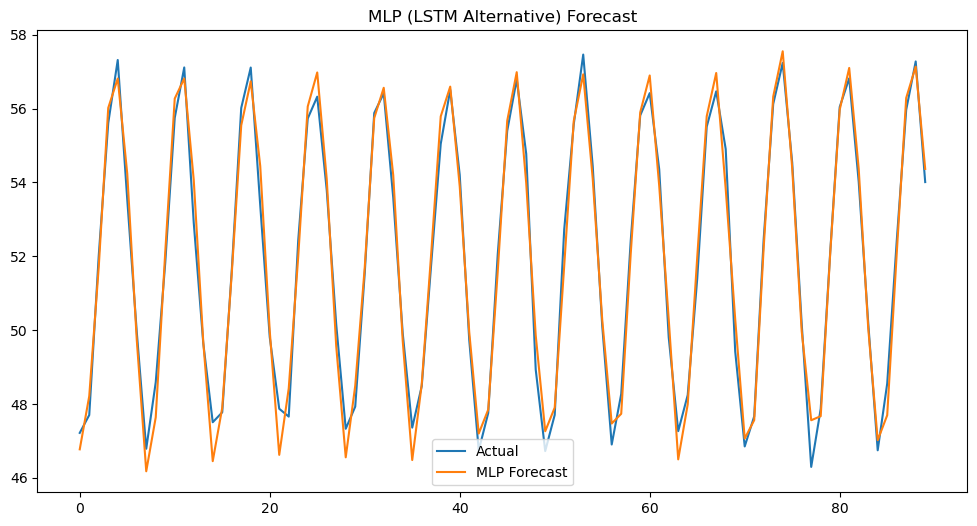

In [10]:
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1,1))

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape_val = mape(y_test_inv, y_pred_inv)

print("MLP Forecasting -> MAE:", mae, "RMSE:", rmse, "MAPE:", mape_val)

plt.figure(figsize=(12,6))
plt.plot(y_test_inv[:100], label="Actual")
plt.plot(y_pred_inv[:100], label="MLP Forecast")
plt.legend()
plt.title("MLP (LSTM Alternative) Forecast")
plt.show()

In [13]:
results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "MLP"],
    "MAE": [arima_mae, sarima_mae, mae],
    "RMSE": [arima_rmse, sarima_rmse, rmse],
    "MAPE": [arima_mape, sarima_mape, mape_val]
})

print(results)

    Model       MAE      RMSE      MAPE
0   ARIMA  0.574688  0.670161  1.106982
1  SARIMA  0.339741  0.417356  0.655348
2     MLP  0.434793  0.529601  0.849711
